# Temporal Data and Centrality Metrics

## 1.Introduction

This chapter introduces **temporal data** and explores stock market trend analysis using **centrality metrics on dynamic networks**. It covers how to transform time-based datasets into **network slices**, apply centrality algorithms to detect structural changes over time, and predict market shifts like price spikes and crashes.

Time series data points are often dependent on previous values and influenced by external factors, making them challenging for many supervised learning methods that assume independence and require known predictors. Specialized algorithms like ARIMA, singular spectrum analysis (SSA), and Holt–Winters models are designed to handle time series data but can **struggle with sudden changes such as spikes, crashes, or shifts in variance**. Understanding trends and external influences is crucial for creating predictive models or identifying factors affecting the data. In complex domains like finance, where many social and economic factors impact stock prices, analyzing and predicting time series data is especially important.

Stock market analytics has increasingly embraced machine learning to detect subtle trends and process vast, complex datasets across global markets. Graph analytics enhances this by modeling correlations between stocks as networks, allowing analysts to detect structural patterns, tipping points, and system-wide vulnerabilities. **Centrality metrics** and other graph-based techniques provide deeper insight into market dynamics than traditional tools, improving the prediction of critical changes like crashes or growth phases. We will discuss about 3 main categories:

A. **Degree Centrality**  
This metric counts the number of direct connections a node has, indicating its immediate influence in the network.

B. **Eigenvector Centrality**  
Unlike degree centrality, this measure also considers the importance of a node's neighbors, assigning higher scores to nodes connected to other highly connected nodes.

C. **Edge Centrality**  
This evaluates the significance of an edge based on how crucial it is to the network’s structure, often measured by how frequently it appears on the shortest paths between nodes.

## 2. Centrality Metrics intorodcution


#### A. **Degree centrality** 

- **Vertex-based centrality** (like degree) measures local influence (connections to neighbors)
- **Degree centrality** is simple and scalable but only reflects immediate connections.
- **Limitation:** Degree centrality can miss a node’s broader influence if it's connected to important nodes, even with few direct links. It is useful but doesn’t tell the whole story

#### B. **Eigenvector centrality**

For deeper insights, we need to look beyond immediate neighbors. This can be achieved by Eigenvector centrality techniques:

| **Metric**           | **What It Measures**                                                     | **Key Mechanism**                                                          | **Handles Disconnected Nodes?** | **Scalability**     | **Best Used For**                                              | **Analogy**                                                                 | **Simple Algorithm Explanation**                                                                 |
|----------------------|--------------------------------------------------------------------------|----------------------------------------------------------------------------|-------------------------------|-------------------|----------------------------------------------------------------|----------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------|
| **Basic Eigenvector**| Importance based on how important your neighbors are                     | Solves eigenvector equation using the adjacency matrix                     | ❌ No                          | ⚠️ Moderate         | Well-connected, undirected networks with strong central hubs   | "I'm important if my **friends are important**."                            | Repeatedly multiply the adjacency matrix by a vector and normalize until it converges.          |
| **PageRank**         | Importance based on random walks and global reachability                 | Random walk with a chance to jump anywhere; uses adjusted adjacency matrix | ✅ Yes                         | ✅ Very high         | Large-scale, web-like networks (e.g., websites, social graphs) | "I'm important if **many people can eventually reach me**, even by chance." | Simulate a random walk with teleportation; iterate until rank scores stabilize.                 |
| **Katz**             | Influence from **all connections**, direct and indirect (even weak ones), friend of friends | Adds up all paths to a node, short ones count more, includes a base score  | ✅ Yes                         | ⚠️ Moderate to High | Networks where **every node matters**, even the less connected | "I'm important because **anyone can reach me**, and no one is left out."    | Sum influence of all paths to a node, decaying with path length; add a small bias term.         |


#### C. **Edge-based centrality**






Edge centrality can be more helpful than degree or eigenvector centrality when understanding the flow of information, traffic, or influence through connections themselves is more critical than simply identifying influential nodes.


| **Metric**                 | **What It Measures**                                                           | **Key Mechanism**                                                                       | **Handles Disconnected Nodes?**        | **Scalability**                   | **Best Used For**                                                       | **Analogy**                                                      | **Simple Algorithm Explanation**                                                                         |
| -------------------------- | ------------------------------------------------------------------------------ | --------------------------------------------------------------------------------------- | -------------------------------------- | --------------------------------- | ----------------------------------------------------------------------- | ---------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------- |
| **Betweenness Centrality** | Importance of a **node** based on how many shortest paths pass through it      | Counts how often a node appears in shortest paths between all node pairs                | ❌ No                                   | ❌ Low (needs parallelization)     | Identifying influential people or brokers in communication networks     | "I'm important because **many conversations route through me**." | For each node pair, find all shortest paths and count how often each node (excluding endpoints) appears. |
| **Edge Betweenness**       | Importance of an **edge** based on how many shortest paths go through it       | Counts how often an edge appears in the shortest paths between all node pairs           | ❌ No                                   | ❌ Low (needs parallelization)     | Small to medium networks with clear traffic or flow dependencies        | "I'm essential because **many travelers pass through me**."      | For each node pair, find all shortest paths and count how often each edge is used.                       |
| **Forman–Ricci Curvature** | Local structural importance of an edge based on surrounding node degrees       | Subtracts the degrees of the two connected vertices from 2                              | ✅ Yes                                  | ✅ High                            | Large-scale or financial networks needing fast curvature-based analysis | "I'm strong if **my neighborhood is tight and simple**."         | * FRC = 2 - ($deg_{A} + deg_{B}$) <br> * The more negative means the more busy                    |
| **Flow Betweenness**       | Importance of an edge in enabling **maximum possible flow** between node pairs | Calculates how much flow an edge carries in max-flow computations across all node pairs | ⚠️ Partially (only if flow is defined) | ❌ Low (computationally expensive) | Capacity-aware systems like **logistics**, **telecom**, **utilities**   | "I'm vital because **traffic can't flow if I'm down**."          | * For all node pairs, compute max flow and measure how much of that flow uses each edge.<br> |



$x_{i+1} = \frac{x}{y}$

## 3. Import and Analyze Stock Market Data 

### Import

Now we will consider the analysis of NASDAQ stock data for Apple, Alphabet, Nvidia, and Microsoft from August 19, 2004, to April 1, 2020, highlighting key trends and market volatility during events like the 2008 financial crisis and the 2020 COVID-19 crash. We will explain the importance of windowing in time series analysis, noting the trade-offs in window size and overlap, with a 5-day window and 4-day overlap chosen to capture short-term trends relevant to day trading.

In [1]:
#import packages
import igraph as ig
from igraph import Graph
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from utils import *

In [2]:
#import Apple and Alphabet stock data

File="/home/sako/Data science lessons/Graph Theory/Modern-Graph-Theory-Algorithms-with-Python-main/data/AAPL_GOOGL_Stock_2004_2020.csv"
pwd=os.getcwd()
os.chdir(os.path.dirname(File))
mydata=pd.read_csv(os.path.basename(File),encoding='latin1')
mydata.index = pd.to_datetime(mydata.Date)

In [3]:
mydata.sample(5)

,Date,Apple Close,Alphabet Close,Nvidia Close,Microsoft Close
Date,,,,,
2007-12-17,12/17/2007,26.342857,334.949951,33.279999,34.389999
2013-06-04,6/4/2013,64.187141,429.979981,14.470000,34.990002
2019-11-18,11/18/2019,267.100006,1319.839966,212.279999,150.339996
2015-04-10,4/10/2015,127.099998,548.539978,22.760000,41.720001
2007-10-04,10/4/2007,22.320000,289.804810,35.980000,29.709999


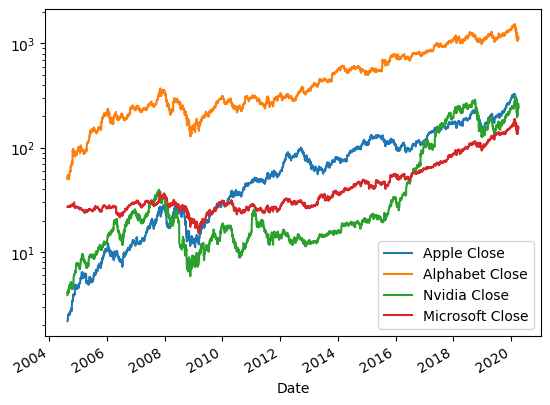

In [4]:
mydata.plot()
plt.yscale('log')

In [5]:
mydata.shape

(3932, 5)

In [6]:
mydata.iloc[(0):(5),1:5]

,Apple Close,Alphabet Close,Nvidia Close,Microsoft Close
Date,,,,
2004-08-19,2.193571,50.220219,3.886667,27.120001
2004-08-20,2.200000,54.209209,4.116667,27.200001
2004-08-23,2.220000,54.754753,4.206666,27.240000
2004-08-24,2.282143,52.487488,4.050000,27.240000
2004-08-25,2.360714,53.053055,4.223333,27.549999


**Notes**
1. Some calculations might be slow (e.g. Betweenes centrality), it might be useful to run window parallelization to extract the values**
2. As this is a undirected graph analysis, the degree of each node is doubled with every connected edge
3. The Forman-Ricci formula calculates for also 2 directions when it is undirected

### Centrality data for the 1st window

In [7]:
#script to create time slices, derive networks, and compute centrality metrics
stock_networks=[]
bet_t=[]
deg_t=[]
eig_t=[]
vcurv_t=[]
bet_ave=[]
deg_ave=[]
eig_ave=[]
vcurv_ave=[]

Date = 5

# --- Wrangle data into graph
data=mydata.iloc[(Date-5):(Date),1:5] # select 5 dates and 4 stock columns
cor_orig=np.corrcoef(data.transpose()) # calculate correlation and transpose
cor = cor_orig.copy()
cor[cor>=0.5]=1 
cor[cor<0.5]=0  
stock_data=Graph.Adjacency(cor)
stock_networks.append(stock_data)

# --- Derive some centrality metrics
# Degress
d=Graph.degree(stock_data)
deg_t.append(d)
deg_ave.append(np.mean(d))

# Betweeness
b=Graph.betweenness(stock_data)
bet_t.append(b)
bet_ave.append(np.mean(b))

# PageRank
e=Graph.pagerank(stock_data)
eig_t.append(e)
eig_ave.append(np.mean(e))

# create Forman-Ricci curvature calculations
ecurvw=[]

for edge in stock_data.es: # es -> stands for edge sequence
    s=edge.source
    t=edge.target
    ecurvw.append(2-d[s]-d[t]) #Forman-Ricci formula for each source and target (edge)
    
vcurvw = []
for vertex in stock_data.vs: # iterate for every vertex -> this follows the "es" sequence 
    inc = Graph.incident(stock_data,vertex) # these gives you the incident edges on a vertex, remember they are undirected => x2 
    inc_curv=[]
    for i in inc:
        inc_curv.append(ecurvw[i]) # collects the curvature values for both directions 
    vcurvw.append(sum(inc_curv)) # sum them to get for each vertex value
vcurv_t.append(vcurvw)
vcurv_ave.append(np.mean(vcurvw))

Let's plot the connections

In [8]:
cor_orig

array([[1.        , 0.06719504, 0.52065734, 0.92787123],
       [0.06719504, 1.        , 0.85924314, 0.26702205],
       [0.52065734, 0.85924314, 1.        , 0.70956225],
       [0.92787123, 0.26702205, 0.70956225, 1.        ]])

In [9]:
cor

array([[1., 0., 1., 1.],
       [0., 1., 1., 0.],
       [1., 1., 1., 1.],
       [1., 0., 1., 1.]])

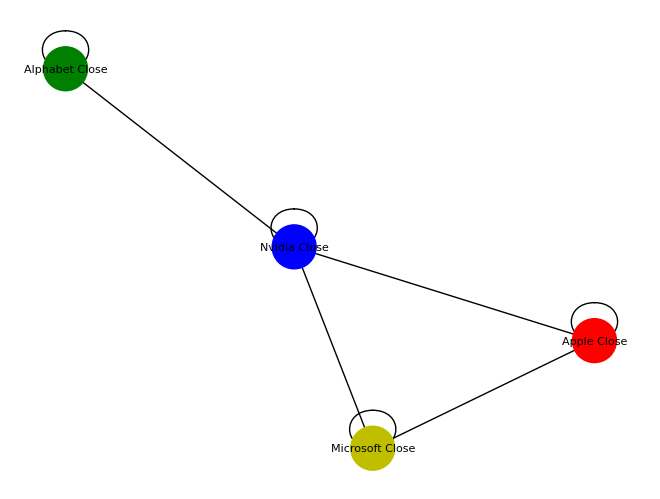

In [10]:
plot_spring_layout(cor,
                   font_size = 8,
                   node_labels=data.columns,
                   node_colors=['r','g','b','y'])

Let's indivually look at the FR calculations and construct a origin-destination matrix (Note that it will be symmetric)

In [11]:
vis = 0*cor_orig
for edge in stock_data.es: # es -> stands for edge sequence
    s=edge.source
    t=edge.target
    val = 2-d[s]-d[t]
    ecurvw.append(val) #Forman-Ricci formula for each source and target (edge)
    print(f"{s}-->{t} = {val}")


    vis[s,t] = val
print("\nThe FR matrix=\n")
print(vis)

print(f"\n sum of the FR matrix = {vis.sum(axis=1)}")

0-->0 = -10
0-->2 = -12
0-->3 = -10
1-->1 = -6
1-->2 = -10
2-->0 = -12
2-->1 = -10
2-->2 = -14
2-->3 = -12
3-->0 = -10
3-->2 = -12
3-->3 = -10

The FR matrix=

[[-10.   0. -12. -10.]
 [  0.  -6. -10.   0.]
 [-12. -10. -14. -12.]
 [-10.   0. -12. -10.]]

 sum of the FR matrix = [-32. -16. -48. -32.]


Let's summarize all the centrality matrix for this window

In [12]:
df_window = pd.DataFrame()
df_window['Nodes'] = mydata.iloc[:,1:5].columns
df_window['Degree'] = d
df_window['Betweeness'] = b
df_window['PageRank'] = e
df_window['FR'] = vcurvw
df_window

,Nodes,Degree,Betweeness,PageRank,FR
0,Apple Close,6,0.0,0.245464,-32
1,Alphabet Close,4,0.0,0.184988,-16
2,Nvidia Close,8,4.0,0.324084,-48
3,Microsoft Close,6,0.0,0.245464,-32


### Centrality data for all the timeseries windows with cor>0.5

In [13]:
#script to create time slices, derive networks, and compute centrality metrics
stock_networks=[]
bet_t=[]
deg_t=[]
eig_t=[]
vcurv_t=[]
bet_ave=[]
deg_ave=[]
eig_ave=[]
vcurv_ave=[]

for Date in range(5,3932):
    
    # --- Wrangle data into graph
    data=mydata.iloc[(Date-5):(Date),1:5] # select 5 dates and 4 stock columns
    cor_orig=np.corrcoef(data.transpose()) # calculate correlation and transpose
    cor = cor_orig.copy()
    cor[cor>=0.5]=1 
    cor[cor<0.5]=0  
    stock_data=Graph.Adjacency(cor)
    stock_networks.append(stock_data)
    
    # --- Derive some centrality metrics
    # Degress
    d=Graph.degree(stock_data)
    deg_t.append(d)
    deg_ave.append(np.mean(d))
    
    # Betweeness
    b=Graph.betweenness(stock_data)
    bet_t.append(b)
    bet_ave.append(np.mean(b))

    # PageRank
    e=Graph.pagerank(stock_data)
    eig_t.append(e)
    eig_ave.append(np.mean(e))
    
    # create Forman-Ricci curvature calculations
    ecurvw=[]
    
    for edge in stock_data.es: # es -> stands for edge sequence
        s=edge.source
        t=edge.target
        ecurvw.append(2-d[s]-d[t]) #Forman-Ricci formula for each source and target (edge)
        
    vcurvw = []
    for vertex in stock_data.vs: # iterate for every vertex -> this follows the "es" sequence
        inc = Graph.incident(stock_data,vertex) # these gives you the incident edges on a vertex
        inc_curv=[]
        for i in inc:
            inc_curv.append(ecurvw[i]) # collects the curvature values for both directions
        vcurvw.append(sum(inc_curv)) # sum them
    vcurv_t.append(vcurvw)
    vcurv_ave.append(np.mean(vcurvw))


In [14]:
#examine correlations among metrics across the time series
print(f'[INFO]:  R^2 -> Degrees   vs  PageRank   = { np.corrcoef(deg_ave,eig_ave)[0,1] :.2f}')
print(f'[INFO]:  R^2 -> Degrees   vs  Betweenes  = { np.corrcoef(deg_ave,bet_ave)[0,1] :.2f}')
print(f'[INFO]:  R^2 -> Degrees   vs  FR         = { np.corrcoef(deg_ave,vcurv_ave)[0,1] :.2f}')
print(f'[INFO]:  R^2 -> PageRank  vs  Betweenes  = { np.corrcoef(eig_ave,bet_ave)[0,1] :.2f}')
print(f'[INFO]:  R^2 -> PageRank  vs  FR         = { np.corrcoef(eig_ave,vcurv_ave)[0,1] :.2f}')
print(f'[INFO]:  R^2 -> Betweenes vs  FR         = { np.corrcoef(bet_ave,vcurv_ave)[0,1] :.2f}')



[INFO]:  R^2 -> Degrees   vs  PageRank   = -0.05
[INFO]:  R^2 -> Degrees   vs  Betweenes  = 0.01
[INFO]:  R^2 -> Degrees   vs  FR         = -0.99
[INFO]:  R^2 -> PageRank  vs  Betweenes  = 0.04
[INFO]:  R^2 -> PageRank  vs  FR         = 0.04
[INFO]:  R^2 -> Betweenes vs  FR         = 0.05


**Note**: Degree centrality and Forman–Ricci curvature centrality are highly correlated **(-0.99)** and may be used interchangeably in this analysis, while other centrality metrics show weak correlations with each other.

array([[<Axes: title={'center': 'Degress'}>,
        <Axes: title={'center': 'PageRank'}>],
       [<Axes: title={'center': 'FR'}>,
        <Axes: title={'center': 'Betweeness'}>]], dtype=object)

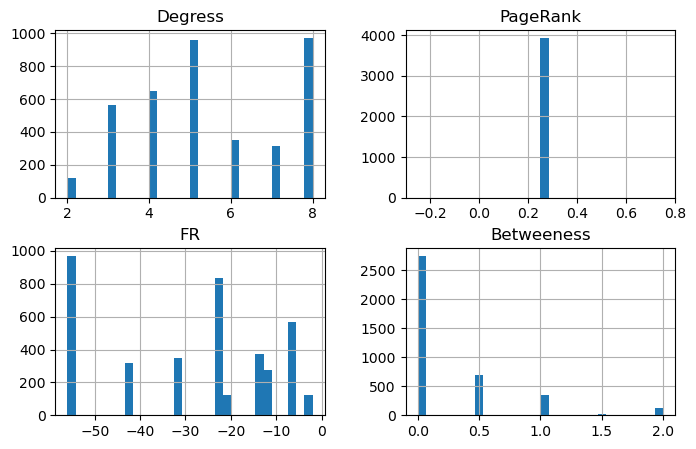

In [15]:
df_metrics = pd.DataFrame()
df_metrics['Degress'] = deg_ave
df_metrics['PageRank'] = np.round(eig_ave,decimals=4)
df_metrics['FR'] = vcurv_ave
df_metrics['Betweeness'] = bet_ave
df_metrics.hist(bins=30,figsize=(8, 5), layout=(2, 2))

In [16]:
# Low variance causes the hist to not appear
for i in df_metrics['PageRank'].unique(): print(i)

0.25


The histograms show that most of the values are randomly distributed

Also looking at the distributions tells us the following: 
1. Negative Forman–Ricci curvature reflects tight market coupling, a sign of volatility or systemic risk. When the values are negative it means the network is connected, and that means prices are moving together due to spikes and market crashes. 
2. Using 0.5 correlationn thresholds tells us that most of the time the FR is very negative => There is crisis all the time, which is not neccesarly true.
3. The Crises happened only a few time and we know it as a fact. We need to tune the thresholds
4. Also the degree distribution tells you from it's distribution that we often have many hubs, which indicates many correlations hence alot of crashes eveywhere. 

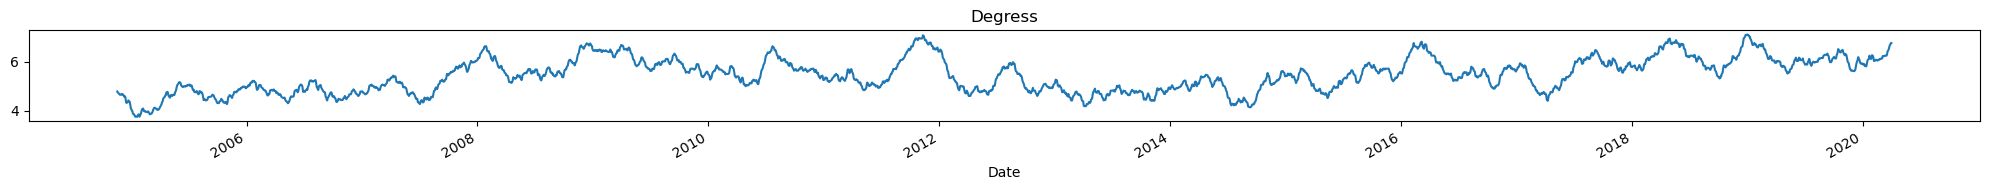

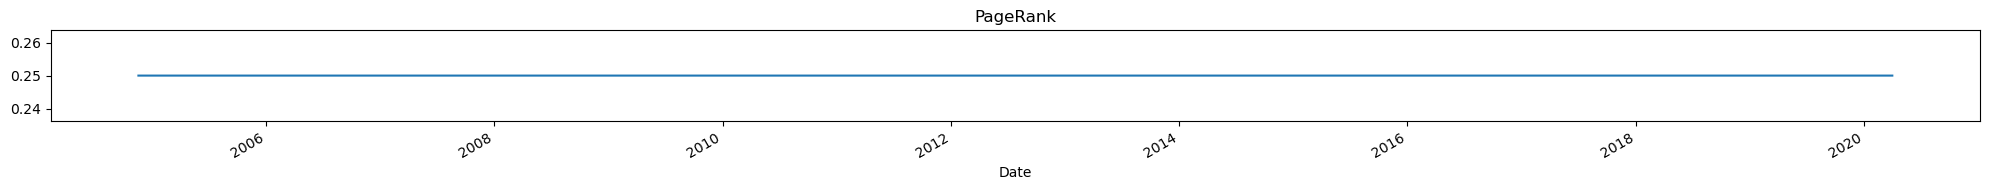

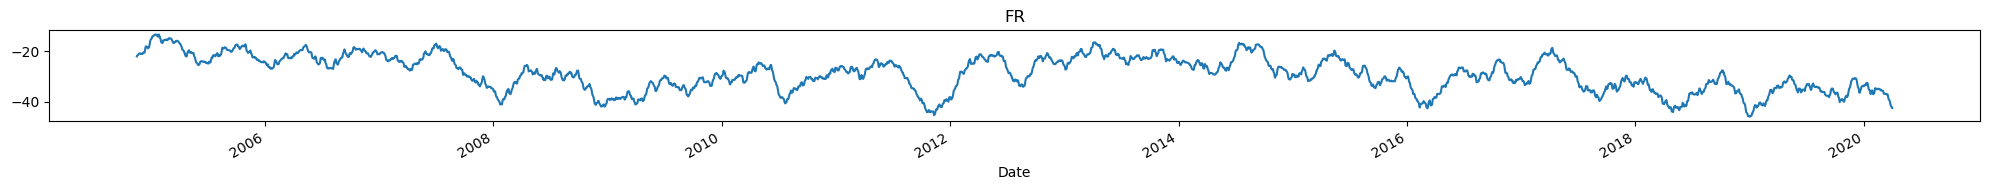

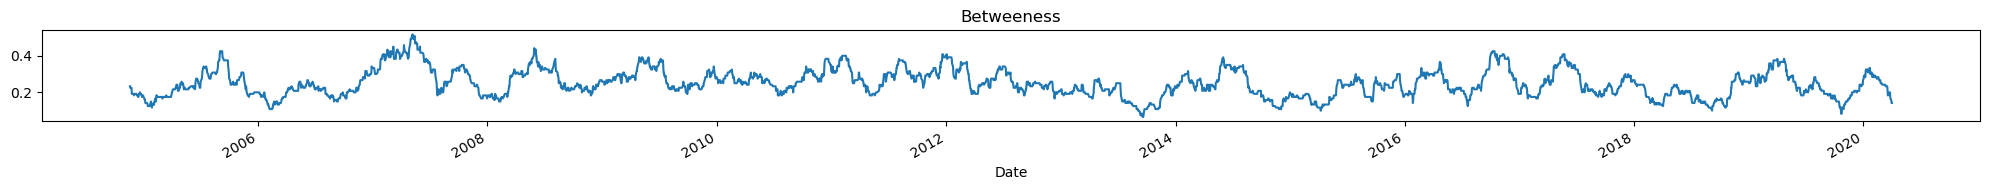

In [17]:
# Column names
columns = df_metrics.columns

df_metrics.index = mydata.index[5:]

df_temp = df_metrics.rolling(60).mean()

# Plot each column
for i, col in enumerate(columns):
    df_temp[col].plot(title=col,figsize=(20,2))
    plt.tight_layout()
    plt.show()

df_cor_5 = df_metrics.copy()    

### Centrality data for all the timeseries windows with cor>0.9

In [18]:
#script to create time slices, derive networks, and compute centrality metrics
stock_networks=[]
bet_t=[]
deg_t=[]
eig_t=[]
vcurv_t=[]
bet_ave=[]
deg_ave=[]
eig_ave=[]
vcurv_ave=[]

for Date in range(5,3932):
    
    # --- Wrangle data into graph
    data=mydata.iloc[(Date-5):(Date),1:5] # select 5 dates and 4 stock columns
    cor_orig=np.corrcoef(data.transpose()) # calculate correlation and transpose
    cor = cor_orig.copy()
    cor[cor>=0.9]=1 
    cor[cor<0.9]=0  
    stock_data=Graph.Adjacency(cor)
    stock_networks.append(stock_data)
    
    # --- Derive some centrality metrics
    # Degress
    d=Graph.degree(stock_data)
    deg_t.append(d)
    deg_ave.append(np.mean(d))
    
    # Betweeness
    b=Graph.betweenness(stock_data)
    bet_t.append(b)
    bet_ave.append(np.mean(b))

    # PageRank
    e=Graph.pagerank(stock_data)
    eig_t.append(e)
    eig_ave.append(np.mean(e))
    
    # create Forman-Ricci curvature calculations
    ecurvw=[]
    
    for edge in stock_data.es: # es -> stands for edge sequence
        s=edge.source
        t=edge.target
        ecurvw.append(2-d[s]-d[t]) #Forman-Ricci formula for each source and target (edge)
        
    vcurvw = []
    for vertex in stock_data.vs: # iterate for every vertex -> this follows the "es" sequence
        inc = Graph.incident(stock_data,vertex) # these gives you the incident edges on a vertex
        inc_curv=[]
        for i in inc:
            inc_curv.append(ecurvw[i]) # collects the curvature values for both directions
        vcurvw.append(sum(inc_curv)) # sum them
    vcurv_t.append(vcurvw)
    vcurv_ave.append(np.mean(vcurvw))


In [19]:
#examine correlations among metrics across the time series
print(f'[INFO]:  R^2 -> Degrees   vs  PageRank   = { np.corrcoef(deg_ave,eig_ave)[0,1] :.2f}')
print(f'[INFO]:  R^2 -> Degrees   vs  Betweenes  = { np.corrcoef(deg_ave,bet_ave)[0,1] :.2f}')
print(f'[INFO]:  R^2 -> Degrees   vs  FR         = { np.corrcoef(deg_ave,vcurv_ave)[0,1] :.2f}')
print(f'[INFO]:  R^2 -> PageRank  vs  Betweenes  = { np.corrcoef(eig_ave,bet_ave)[0,1] :.2f}')
print(f'[INFO]:  R^2 -> PageRank  vs  FR         = { np.corrcoef(eig_ave,vcurv_ave)[0,1] :.2f}')
print(f'[INFO]:  R^2 -> Betweenes vs  FR         = { np.corrcoef(bet_ave,vcurv_ave)[0,1] :.2f}')



[INFO]:  R^2 -> Degrees   vs  PageRank   = -0.04
[INFO]:  R^2 -> Degrees   vs  Betweenes  = 0.44
[INFO]:  R^2 -> Degrees   vs  FR         = -0.98
[INFO]:  R^2 -> PageRank  vs  Betweenes  = 0.00
[INFO]:  R^2 -> PageRank  vs  FR         = 0.04
[INFO]:  R^2 -> Betweenes vs  FR         = -0.39


array([[<Axes: title={'center': 'Degress'}>,
        <Axes: title={'center': 'PageRank'}>],
       [<Axes: title={'center': 'FR'}>,
        <Axes: title={'center': 'Betweeness'}>]], dtype=object)

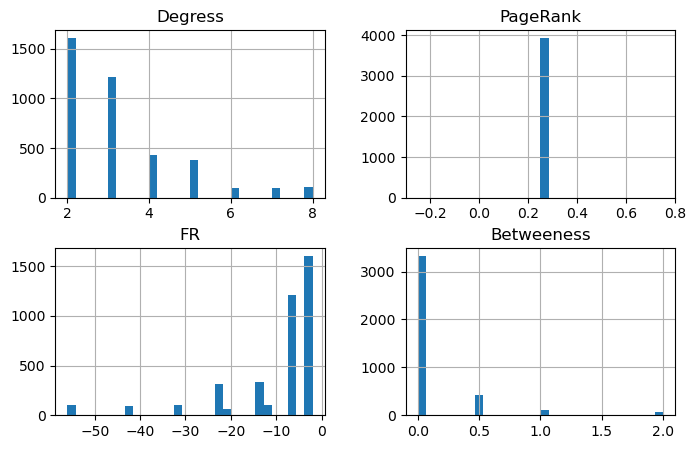

In [20]:
df_metrics = pd.DataFrame()
df_metrics['Degress'] = deg_ave
df_metrics['PageRank'] = np.round(eig_ave,decimals=4)
df_metrics['FR'] = vcurv_ave
df_metrics['Betweeness'] = bet_ave
df_metrics.hist(bins=30,figsize=(8, 5), layout=(2, 2))

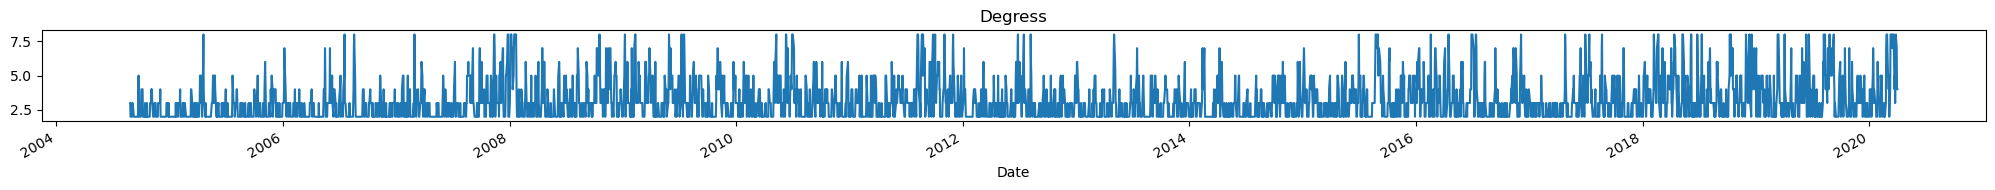

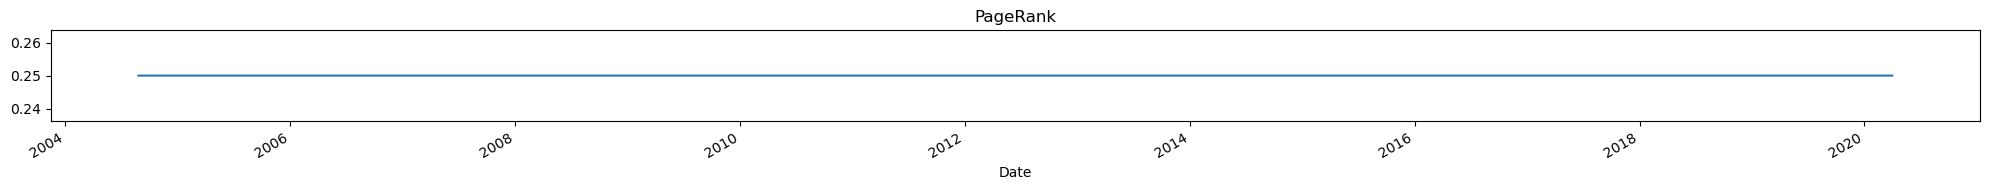

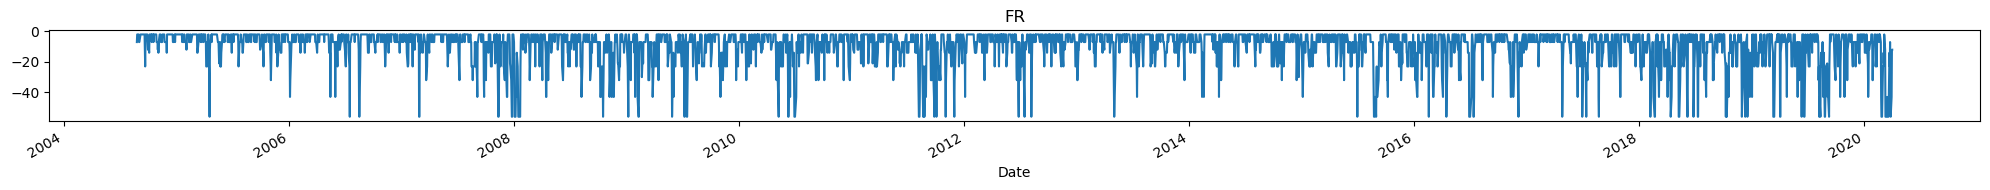

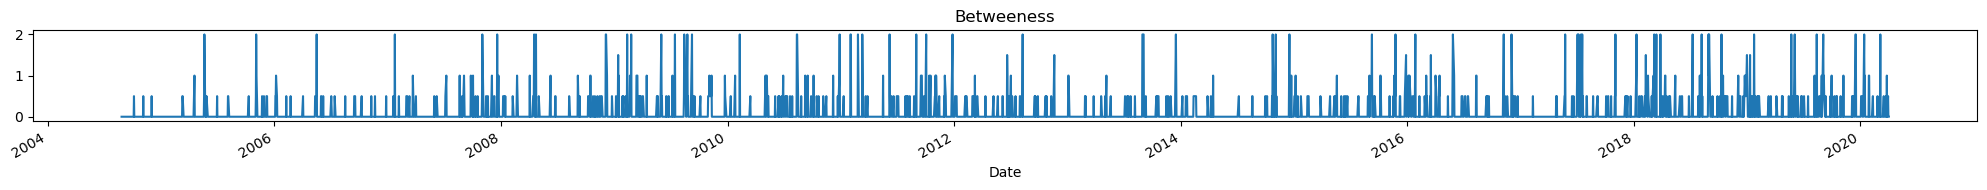

In [21]:
# Column names
columns = df_metrics.columns

df_metrics.index = mydata.index[5:]

# Plot each column
for i, col in enumerate(columns):
    df_metrics[col].plot(title=col,figsize=(20,2))
    plt.tight_layout()
    plt.show()

<Axes: xlabel='Date'>

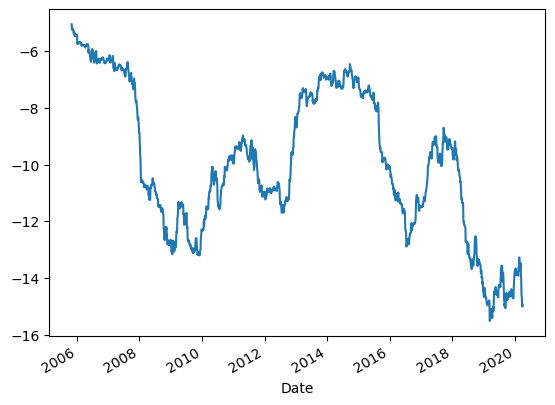

In [22]:
df_metrics.FR.rolling(300).mean().plot()

You can see now the values stablaized better, wehre the negative correlations (market crashes) are more identiable. 

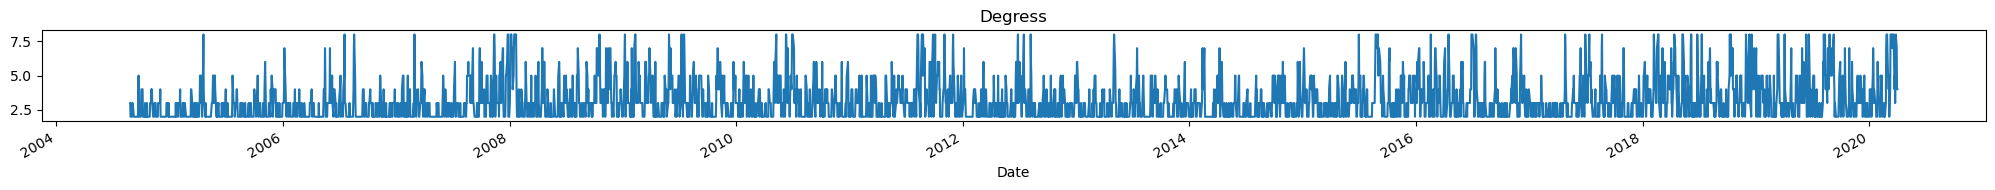

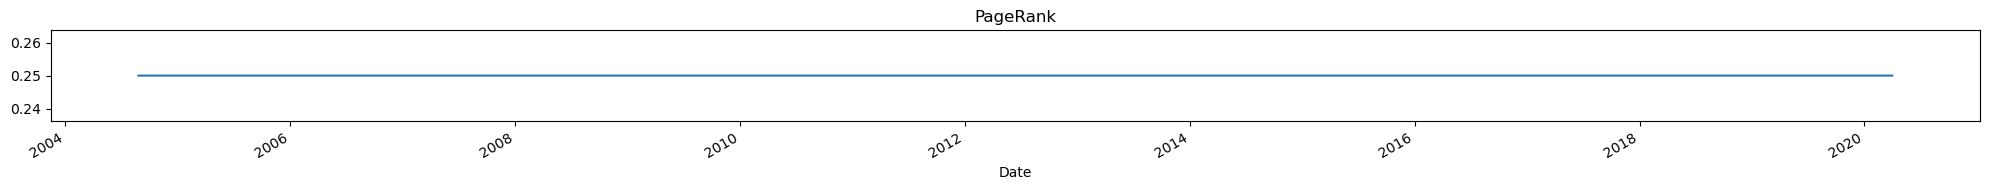

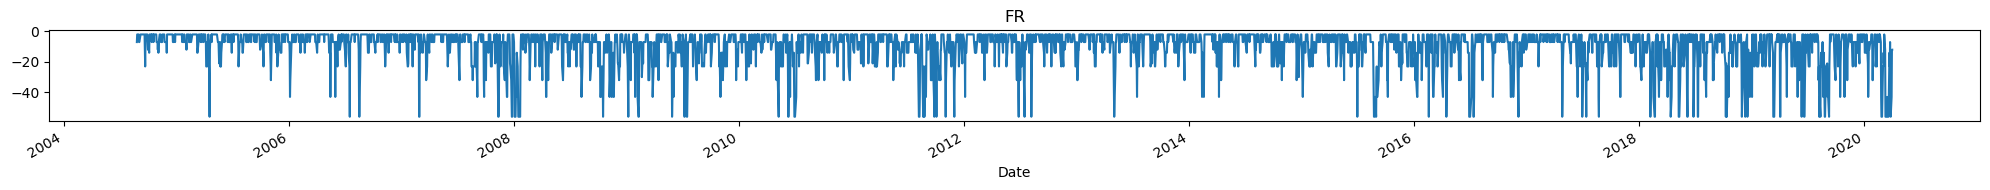

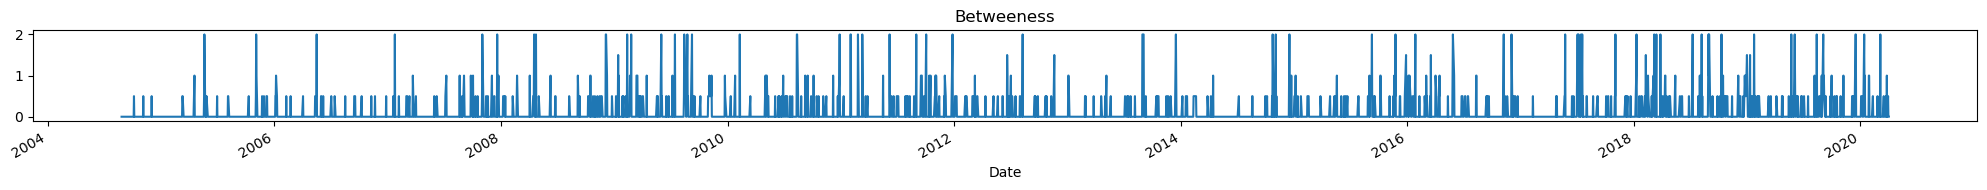

In [23]:
# Column names
columns = df_metrics.columns

df_metrics.index = mydata.index[5:]

# Plot each column
for i, col in enumerate(columns):
    df_metrics[col].plot(title=col,figsize=(20,2))
    plt.tight_layout()
    plt.show()
df_cor_9 = df_metrics.copy()  

### Using Simplicial Complexes

Networks capture **pairwise (2-way) relationships**, but real-world data often involves **higher-order interactions** — among 3, 4, or more entities. **Simplicial complexes** extend networks to capture these **multi-way relationships**:

* A **triangle** represents a **3-way** interaction.
* A **tetrahedron** represents a **4-way** interaction.
* These structures nest, with lower-dimensional faces (2-way line fo triangle) forming the boundaries of higher-dimensional ones.

To construct a simplicial complex from data (like stock correlations):

1. **Define a relationship metric** (e.g. correlation or distance).
2. **Apply thresholds** to build interactions based on proximity or similarity.
3. Choose between:

   * **Vietoris–Rips complex**: connects points whose **balls of radius ε overlap**.
   * **Čech complex**: includes only groups where all **balls mutually overlap**.

By varying the threshold (called **filtration**), we generate different complexes, revealing patterns at multiple scales — like how changing correlation cutoffs in a stock network alters insights. 

--- 

Think of it as each point as a sensor on a tower, and if the networks covers enough space and distance the towers connect. Čech complex is the version where it the calculation take into consideration holes before connecting the tower, but Rips doesn't. Take a look at [the extra jupyter notebook](./Extra%20-%20Chech%20and%20Rip%20Complex%20viusalizer.ipynb) to visualize Čech and Vietoris–Rips complexes and play with the "filteration" parameter.

If you want to drill into it, I recommend to watch lectures 1 to 4 of from the School of Scientific Computing and Imaging Institute(SCI) university of Utah [CS6170 on YouTube taught by Dr. Bei Wang Phillips](https://www.youtube.com/watch?v=P_L3VJp-a2g&list=PLDZ6LA16SDbIvbgmCjcCuTA7mttfXjiec). The topics of persistent homology is explained and a great introductory explanation using advanced linear algebra to full explain simplicial simplexes, Čech, and Rips complexes. 

--- 


### Let's use FR using Rips complex 

For the analysis of the Rips complex to work we need to convert out correlation trend value to something which can be explained from a perspective of distance to vary the threshold epsilon. We will create a function **build_rip_graph** will calcualte the correlation between the trends and convert them into distance matrices using


$$
d(x, y) = \frac{\cos^{-1}(r^2(x, y))}{\pi}
$$


* This formula is a nonlinear transformation that maps a squared correlation value $r^2(x, y) \in [0,1]$ to a normalized distance $d(x, y) \in [0, 0.5]$, and it's rooted in geometry and information theory.
* The FR as we discissed earler the more negative it gets, it means that there are trees and hubs where things are hub dominated. For time series analysis this translates as a crash in the market as the behaviour of clients is the same.

In [24]:
def build_rip_graph(data,eps):


    # pandas correlation matrix is converted into a distance metric for Rip's complex
    corr_matrix = np.arccos(data.corr()) / np.pi

    # build graph 
    g = ig.Graph()
    g.add_vertices(list(corr_matrix.columns))
    
    # Step 4: Add edges based on correlation threshold
    edges = []
    weights = []
    
    for i in range(len(corr_matrix)):
        for j in range(i + 1, len(corr_matrix)):
            dist = corr_matrix.iloc[i, j]
            if dist <= 2*eps:
                source = corr_matrix.columns[i]
                target = corr_matrix.columns[j]
                edges.append((source, target))
                weights.append(abs(corr_matrix))  # or use signed corr
    
    g.add_edges(edges)
    g.es["weight"] = weights

    return g

In [25]:
def get_forman_ricci_metric(graph):
    
    # create Forman-Ricci curvature calculations
    ecurvw = []
    for edge in graph.es: # es -> stands for edge sequence
        s=edge.source
        t=edge.target
        ecurvw.append(2-d[s]-d[t]) #Forman-Ricci formula for each source and target (edge)
        
    vcurvw = []
    for vertex in graph.vs: # iterate for every vertex -> this follows the "es" sequence
        inc = Graph.incident(graph,vertex) # these gives you the incident edges on a vertex
        inc_curv=[]
        for i in inc:
            inc_curv.append(ecurvw[i]) # collects the curvature values for both directions
        vcurvw.append(sum(inc_curv)) # sum them
    return np.mean(vcurvw)

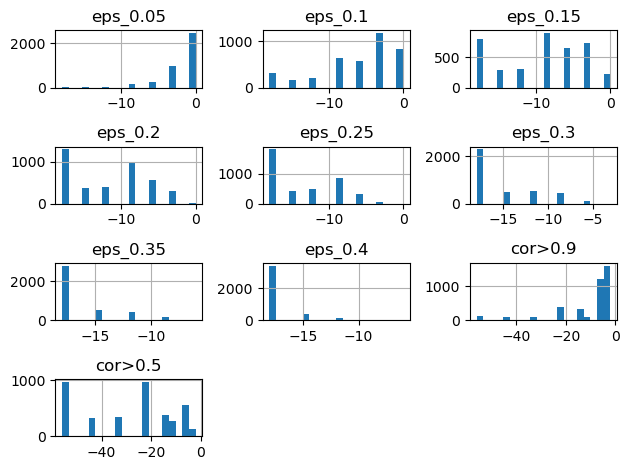

In [31]:
graph_nodes = []
eps = [0.05,0.1,0.15,0.2,0.25,0.3,0.35,0.4]
df_FR = {}
graphs = {} 

window = 5 

for eps_i in eps:
    vcurv_ave = [] 
    for Date in range(window,3932):    
        # --- Wrangle data into graph
        data=mydata.iloc[(Date-window):(Date),1:window] # select 5 dates and 4 stock columns
    
        #--- Build graph 
        graph_rip = build_rip_graph(data,eps_i)

        #Calculate --- forman_ricci   
        vcurv_ave.append(get_forman_ricci_metric(graph_rip))

        #save graphs
        graphs[f"window_{Date}_eps_{eps_i}"] = graph_rip
        
    df_FR[f"eps_{eps_i}"] = vcurv_ave
    


# compile the results o
df_FR = pd.DataFrame(df_FR)
df_FR.index = df_metrics.index
df_FR['cor>0.9'] = df_cor_9['FR']
df_FR['cor>0.5'] = df_cor_5['FR']


# Visualize
df_FR.hist(bins=20)
plt.tight_layout()

<ErrorbarContainer object of 3 artists>

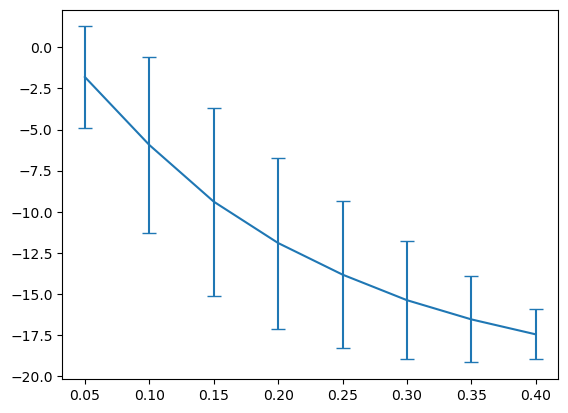

In [32]:
# Mean of the epsilon vs the FR metric
res_mean = df_FR[[i for i in df_FR.columns if 'roll' not in i]].mean().to_frame().reset_index()
res_mean.columns = ['eps','FR_mean']
res_mean[['col','eps_val']] = res_mean['eps'].str.split("_",expand=True)
res_mean = res_mean.query("col=='eps'")
res_mean['eps_val'] = res_mean.eps_val.astype("float")
res_mean = res_mean[['FR_mean','eps_val']]

# Std of the epsilon vs the FR metric
res_std = df_FR[[i for i in df_FR.columns if 'roll' not in i]].std().to_frame().reset_index()
res_std.columns = ['eps','FR_std']
res_std[['col','eps_val']] = res_std['eps'].str.split("_",expand=True)
res_std = res_std.query("col=='eps'")
res_std['eps_val'] = res_std.eps_val.astype("float")
res_std = res_std[['FR_std','eps_val']]

# MErge then to a single table
res = pd.merge(res_mean,res_std,on='eps_val')

# Visualize the change
plt.errorbar(x = res.eps_val, y = res_mean.FR_mean, yerr=res_std.FR_std,capsize=5)

In [33]:
for eps_i in eps:
    temp_val = df_FR[f"eps_{eps_i}"].rolling(400).mean()
    temp_mean = temp_val.mean()
    temp_std= temp_val.std()
    df_FR[f"eps_{eps_i}_roll"] = temp_val

# cor>0.9
temp_val = df_FR[f"cor>0.9"].rolling(400).mean()
temp_mean = temp_val.mean()
temp_std= temp_val.std()
df_FR[f"cor>0.9_roll"] = temp_val

temp_val = df_FR[f"cor>0.5"].rolling(400).mean()
temp_mean = temp_val.mean()
temp_std= temp_val.std()
df_FR[f"cor>0.5_roll"] = temp_val



In [35]:
cols = ['eps_0.05_roll','eps_0.1_roll','eps_0.15_roll','eps_0.3_roll',"cor>0.9_roll","cor>0.5_roll"]

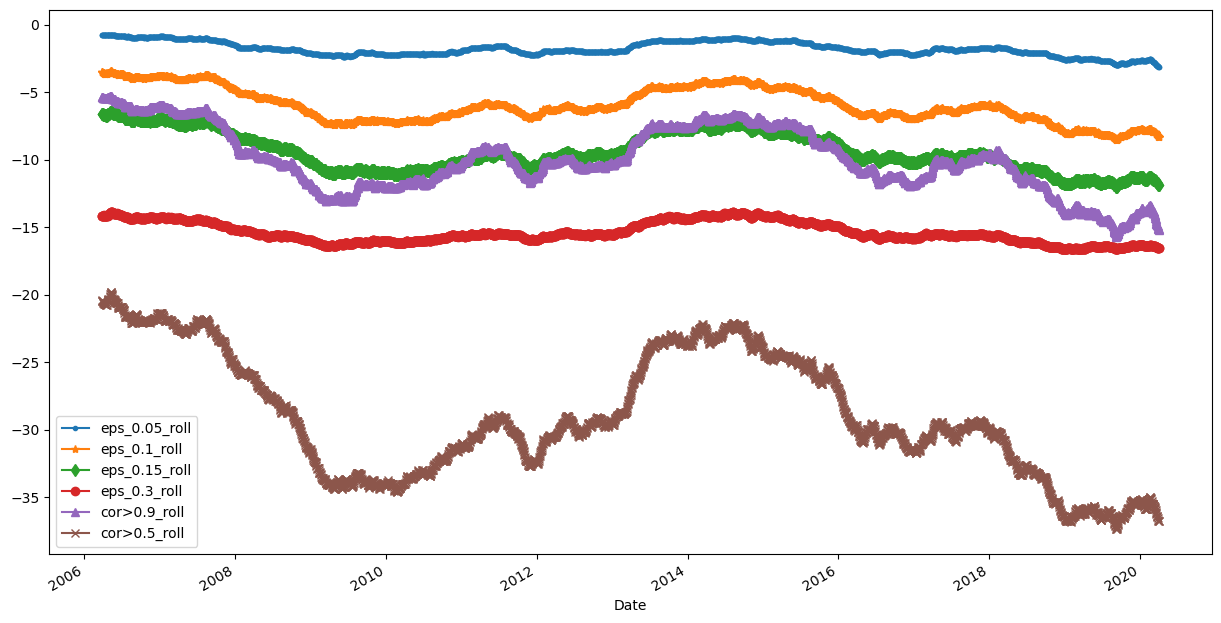

In [36]:
markers = ['.', '*', 'd', 'o',"^","x"]
end = 5000
ax = df_FR[cols].iloc[:end, 0].plot(figsize=(15,8), marker=markers[0], label=cols[0])  # plot first with figsize

for i, col in enumerate(cols[1:], start=1):
    df_FR[col][:end].plot(ax=ax, marker=markers[i], label=col)

plt.legend()
plt.show()

We can see that the correlation > 0.5 has exteremely negative values of FR which shows that it has connected everything together. The crases and the spikes appear extermely. 

## 4.Conclusions

After examining the results and how we constructed the connections from time series data to graph networks, we observed that graphs built using the Rips complex with a threshold of 0.15 produced FR curves very similar to those of graphs created using correlation values greater than 0.9.

This suggests that our choice of method was reasonable for the analysis. However, an interesting observation is that graphs based purely on correlation tend to produce more negative FR values and extreme outcomes. This is likely due to the way distances are mapped: in our case, we used an inverse cosine transformation, which is non-linear and adds a different layer of analysis. With correlation-based graphs, the threshold is imposed directly on each connection, while in the Rips complex, it applies to pairwise distances, enabling a more flexible structure.

Since our network is relatively small, we anticipate that more complex behaviors and structures will emerge when we analyze larger datasets — for example, by including more stock prices or using individual time series such as client transactions. Even in cases where no direct correlations are found, applying pairwise Rips complex-based topological techniques allows us to build alternative graph representations and gain deeper insights from the data.

Thus, using Rips complexes in graph construction offers a robust alternative to correlation-based methods, especially in settings where relationships are not strictly linear or direct, enabling richer analysis of time series data structures.